<a href="https://colab.research.google.com/github/Atharv-Chopade/Machine_Learning/blob/main/RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [70]:
import pandas as pd

In [71]:
from sklearn.datasets import load_breast_cancer

In [72]:
data = load_breast_cancer()
df = pd.DataFrame(data.data , columns = data.feature_names)
df['target'] = data.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [73]:
X = df.drop('target' , axis = 1)
y = df['target']

In [74]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [75]:
X_train , X_test , y_train, y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

In [76]:
model = RandomForestClassifier(n_estimators= 100 , random_state = 50 , max_depth=6)
model.fit(X_train , y_train)

RandomForestClassifier(max_depth=6, random_state=50)

In [77]:
y_pred =  model.predict(X_test)

In [78]:
from sklearn.metrics import accuracy_score , classification_report

In [79]:
print(classification_report(y_pred , y_test))

              precision    recall  f1-score   support

           0       0.93      0.98      0.95        41
           1       0.99      0.96      0.97        73

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



In [80]:
import matplotlib.pyplot as plt

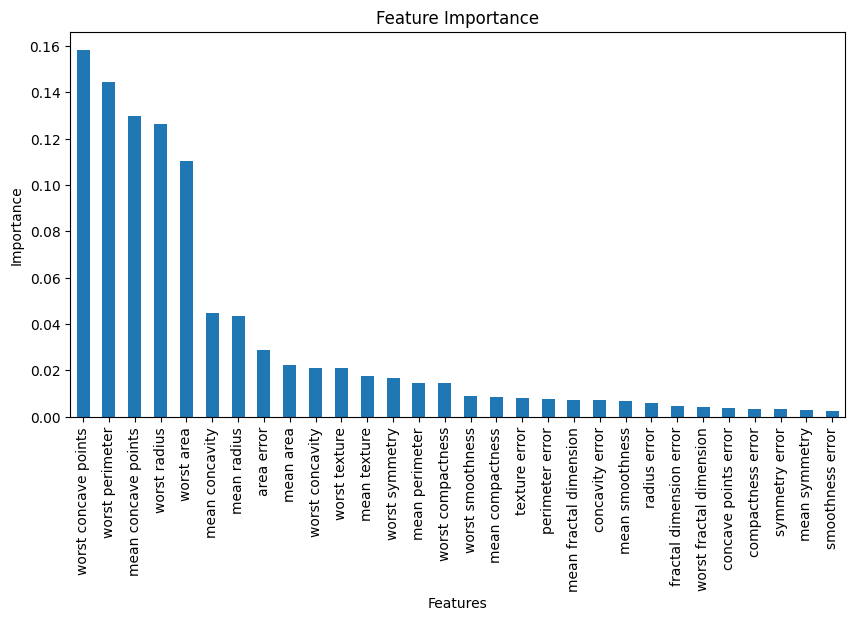

In [81]:
importance = model.feature_importances_
pd.Series(importance , index = X.columns).sort_values(ascending = False).plot(kind = 'bar' , figsize = (10,5))
plt.title('Feature Importance')
plt.ylabel('Importance')
plt.xlabel('Features')
plt.show()

In [82]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [83]:
models = [LogisticRegression() , KNeighborsClassifier() , DecisionTreeClassifier(), RandomForestClassifier()]

In [84]:
acc = []

In [85]:
for model in models:
    model.fit(X_train , y_train)
    y_pred = model.predict(X_test)
    acc.append(accuracy_score(y_pred , y_test))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [89]:
model_names = ['LogisticRegression' , 'KNeighborsClassifier' , 'DecisionTreeClassifier ', 'RandomForestClassifier']
acc

[0.956140350877193, 0.956140350877193, 0.9385964912280702, 0.9649122807017544]

In [97]:
import seaborn as sns

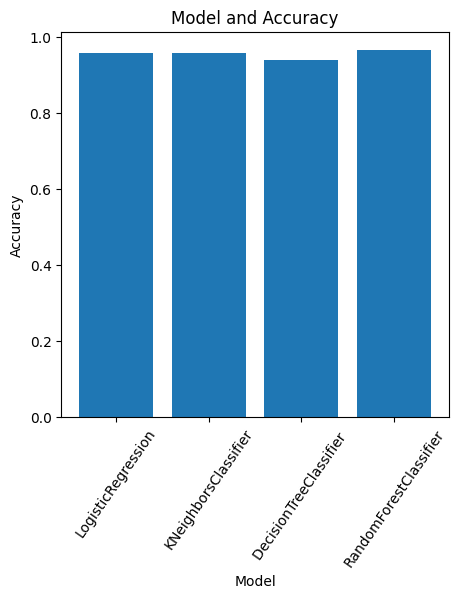

In [103]:
plt.figure(figsize=(5,5))
plt.bar(model_names , acc)
plt.title('Model and Accuracy')
plt.xticks(rotation=55)
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.show()


<Axes: >

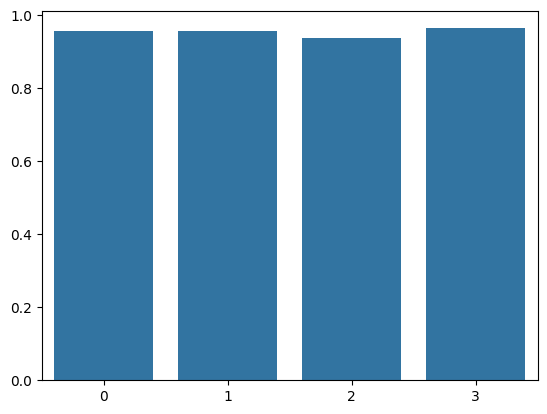